<a href="https://colab.research.google.com/github/abedamatta01/genai4biz/blob/main/BedamattaAbhisekAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

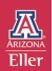

# **MIS 556 - Generative AI for Business**

## Assignment 4 : Demonstrate advanced prompt engineering skills using API services and Google Colab


---
#### FROM: Abhisek Bedamatta
#### Date: 11th Sept 2026


---





### Install Required Libraries

We will install the required libraries and explicitly specify versions to ensure reproducibility and compatibility, especially when working with external APIs like OpenAI. By fixing the library versions, we avoid issues where future updates might break our code due to deprecated methods or API changes.


In [36]:
!pip install openai==0.28.1 python-dotenv --quiet

### Load and Preview Review Data

We'll read 500 Amazon reviews from a text file Amazon-reviews.txt located in GitHub repo genai4biz. Each review starts with the prefix `REVIEW:`. We'll strip the prefix and store the reviews in a list for further processing.

You can find the review data, on GitHub:  
🔗 [https://github.com/abedamatta01/genai4biz/blob/main/Amazon-reviews.txt](https://github.com/abedamatta01/genai4biz/blob/main/Amazon-reviews.txt)


In [39]:
import pandas as pd
import requests

# Load reviews from the reviews_samples.txt file
url = "https://raw.githubusercontent.com/abedamatta01/genai4biz/refs/heads/main/Amazon-reviews.txt"

response = requests.get(url)
lines = response.text.splitlines()

# read each line to get individual review
reviews = [line.strip().replace("REVIEW: ", "") for line in lines if line.startswith("REVIEW:")]

# Preview the first few reviews
pd.set_option("display.max_colwidth", None)
df_reviews = pd.DataFrame(reviews, columns=["Review"])
df_reviews.head(2).style.set_properties(**{'text-align': 'left'})

,Review
0,Tape work well
1,I used the duct tape to do some repairs and the tape worked great plus added some colors where I needed it.


#### **Task 1** : Count and show the number of reviews

A count of the rows in the DataFrame after parsing. It is worth printing rather than assuming, because the count also confirms that no lines were lost to blank rows or a missing prefix during loading.

In [40]:
num_reviews = len(df_reviews)
print(f"Number of reviews loaded: {num_reviews}")

Number of reviews loaded: 500


#### **Task 2** : Count the numbers of words in all the reviews, show their basic statistics, and visualize the distribution of the numbers of words in all reviews

A word here is a whitespace-delimited token, which is the ordinary reading of the question and needs no tokenizer. `describe()` gives the count, mean, standard deviation, minimum, quartiles, and maximum in one call.

The reason length matters at all is that Tasks 3 through 5 only apply to reviews longer than fifteen words, so this statistic decides how much of the corpus goes to the API. The histogram makes that visible: the vertical line at fifteen words is the cut-off, and everything to the right of it is what gets scored.

Basic statistics for the number of words per review:

count    500.000000
mean      21.200000
std       23.113816
min        1.000000
25%        7.000000
50%       15.000000
75%       25.250000
max      157.000000
Name: WordCount, dtype: float64

Median: 15.0
Total words across all reviews: 10,600


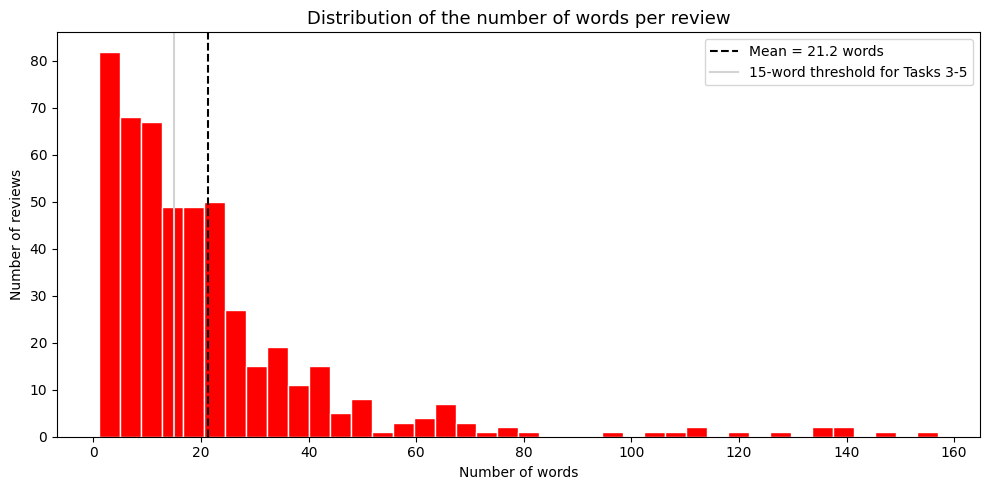

In [41]:
import matplotlib.pyplot as plt

# Word count per review
df_reviews["WordCount"] = df_reviews["Review"].str.split().str.len()

# Basic statistics
word_stats = df_reviews["WordCount"].describe()
print("Basic statistics for the number of words per review:\n")
print(word_stats)
print(f"\nMedian: {df_reviews['WordCount'].median():.1f}")
print(f"Total words across all reviews: {df_reviews['WordCount'].sum():,}")

# Distribution of review lengths
plt.figure(figsize=(10, 5))
plt.hist(df_reviews["WordCount"], bins=40, color="red", edgecolor="white")
plt.axvline(df_reviews["WordCount"].mean(), color="black", linestyle="--",
            label=f"Mean = {df_reviews['WordCount'].mean():.1f} words")
plt.axvline(15, color="lightgrey", linestyle="-",
            label="15-word threshold for Tasks 3-5")
plt.title("Distribution of the number of words per review", fontsize=13)
plt.xlabel("Number of words")
plt.ylabel("Number of reviews")
plt.legend()
plt.tight_layout()
plt.show()

**Observation.** The distribution is right-skewed, which is the usual shape for review data: most customers write a line or two and a small number write at length, so the mean sits above the median and a long tail runs out to the right. Mean of about **21** words, median of about **15**, and a maximum of **157**

### Configure the OpenAI API Key

To use the OpenAI API, you need to authenticate using your secret key.

In [42]:
import openai
import os
from dotenv import load_dotenv
import getpass

# Load environment variables from .env file if it exists
load_dotenv()

# Attempt to get OpenAI API key from environment variables first
openai_api_key = os.getenv("OPENAI_API_KEY")

# If not found in environment, prompt user to enter it securely
if not openai_api_key:
    openai_api_key = getpass.getpass("Please enter your OpenAI API key: ")
    os.environ["OPENAI_API_KEY"] = openai_api_key

# Verify that the API key has been successfully configured
if openai_api_key:
    print(f"🔑 API key configured (first 10 characters: {openai_api_key[:10]}...)")
    openai.api_key  = os.getenv('OPENAI_API_KEY')
else:
    print("❌ API key not configured, please set your OpenAI API key")

🔑 API key configured (first 10 characters: sk-proj-05...)


#### **Task 3** : Use OpenAI GPT APIs and prompt engineering to predict the sentiment of these reviews with more than 15 words and visualize the predicted sentiment of all the reviews

Reviews of fifteen words or fewer are filtered out first. They are excluded for a reason that is easy to defend: a three-word review like "works as described" carries almost no sentiment signal, and paying for an API call on it adds noise rather than information.

Two helper functions carry the API work for the rest of the notebook. `call_gpt` wraps the chat completion call with retry and exponential back-off, because a run of several hundred sequential calls will occasionally hit a rate limit or a transient network error, and a single failure should not end the loop. `parse_json_response` strips the Markdown code fences that the model sometimes wraps around JSON even when told not to.

In [43]:
import json
import re
import time
from tqdm import tqdm

def call_gpt(prompt, model="gpt-3.5-turbo", temperature=0, max_retries=4):
    """Call the chat completion endpoint with retry and exponential back-off."""
    for attempt in range(max_retries):
        try:
            response = openai.ChatCompletion.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,   # 0 makes the output as deterministic as possible
            )
            return response.choices[0].message["content"]
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            time.sleep(2 ** attempt)

def parse_json_response(text):
    """Strip any Markdown fencing and parse the model output as JSON."""
    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?", "", cleaned).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()
    return json.loads(cleaned)

### The sentiment prompt

The prompt does five things, and each one is there to remove a specific failure mode observed in the Hands-on Demo 3 approach:

1. **A role** puts the model in the right frame before it sees the task.
2. **A fixed label set** of Positive, Neutral, Negative keeps the output countable. A free-text answer would have to be cleaned afterwards.
3. **A 1-to-10 score tied to the label** gives a finer-grained reading for the histogram while keeping the two outputs consistent with each other.
4. **A rule for mixed reviews** settles the most common ambiguous case, where a customer praises the product and complains about one detail.
5. **A strict output format with three worked examples.** Asking for JSON and showing what it should look like is what makes the response parseable without post-processing. The examples also anchor the scale, so an eight means roughly the same thing across five hundred separate calls.

`temperature=0` is set in the helper for the same reason it is used in the course demo: the same review should get the same score every time the notebook runs.

In [44]:
SENTIMENT_PROMPT = """You are an experienced analyst of e-commerce product reviews.

Read the customer review below and judge the sentiment the customer expresses about the product or the purchase.

Rules:
- Label the review as exactly one of: Positive, Neutral, Negative.
- Also give a score from 1 (very negative) to 10 (very positive) that is consistent with the label: 1-4 is Negative, 5-6 is Neutral, 7-10 is Positive.
- Judge only the sentiment that is actually stated. Do not infer feelings the customer did not express.
- A review that praises the product but complains about one small detail is still Positive, unless the complaint dominates the review.
- Return a single JSON object and nothing else, in exactly this form:
{"sentiment": "Positive", "score": 8}

Examples:
Review: "The battery died after two weeks and the seller refused to replace it. Total waste of money."
{"sentiment": "Negative", "score": 2}

Review: "Sound quality is excellent for the price, though the case feels a bit cheap and scratches easily."
{"sentiment": "Positive", "score": 8}

Review: "It arrived on time and works as described. Nothing special either way."
{"sentiment": "Neutral", "score": 5}

Now score this review.
Review: "<<REVIEW>>"
"""

def get_sentiment(review):
    # A placeholder is substituted rather than str.format(), so a review containing
    # a brace character cannot break the prompt template
    raw = call_gpt(SENTIMENT_PROMPT.replace("<<REVIEW>>", review))
    result = parse_json_response(raw)
    return result["sentiment"].strip().capitalize(), int(result["score"])

### Scoring the long reviews

One call per review, with a progress bar so the run can be monitored. Any review that fails all four retries is recorded as `None` rather than stopping the loop, and the count of failures is printed at the end so nothing goes missing silently.

In [45]:
# Keep only the reviews with more than 15 words
df_long = df_reviews[df_reviews["WordCount"] > 15].copy().reset_index(drop=True)

print(f"Reviews with more than 15 words: {len(df_long)} out of {num_reviews} "
      f"({len(df_long) / num_reviews:.1%} of the corpus)")

sentiments, scores = [], []

for review in tqdm(df_long["Review"], desc="Scoring sentiment"):
    try:
        sentiment, score = get_sentiment(review)
    except Exception as e:
        print(f"Failed on review: {review[:60]}... ({e})")
        sentiment, score = None, None
    sentiments.append(sentiment)
    scores.append(score)

df_long["Sentiment"] = sentiments
df_long["Score"] = scores

failures = df_long["Sentiment"].isna().sum()
print(f"\nScored {len(df_long) - failures} reviews. Failures: {failures}")
df_long[["Review", "WordCount", "Sentiment", "Score"]].head(10)

print(df_long["Sentiment"].value_counts())
print("\nShare of each sentiment among the scored reviews:")
print((df_long["Sentiment"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

Reviews with more than 15 words: 248 out of 500 (49.6% of the corpus)


Scoring sentiment: 100%|██████████| 248/248 [04:08<00:00,  1.00s/it]


Scored 248 reviews. Failures: 0
Sentiment
Positive    213
Negative     20
Neutral      15
Name: count, dtype: int64

Share of each sentiment among the scored reviews:
Sentiment
Positive    85.9%
Negative     8.1%
Neutral      6.0%
Name: proportion, dtype: object


### Visualizing the predicted sentiment

Three views, because each answers a different question. The first counts the labels among the reviews that were scored. The second shows how the 1-to-10 scores spread out, which is where partial dissatisfaction shows up that a three-way label flattens. The third puts the scored reviews back in the context of the whole file, with the short reviews shown as their own category so that the chart accounts for all five hundred rather than only the subset sent to the API.

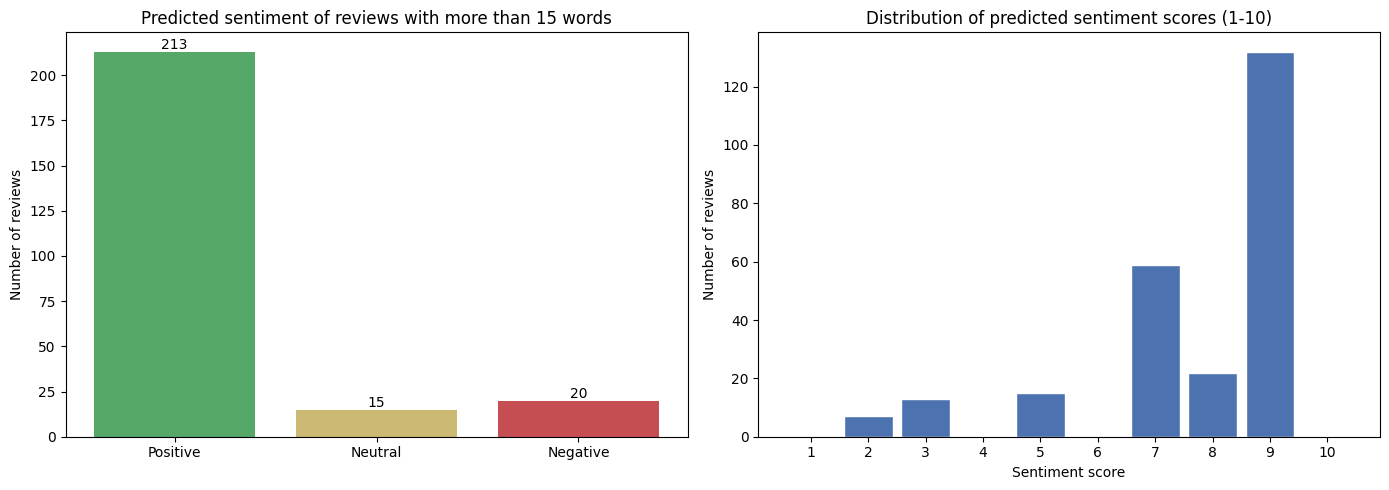

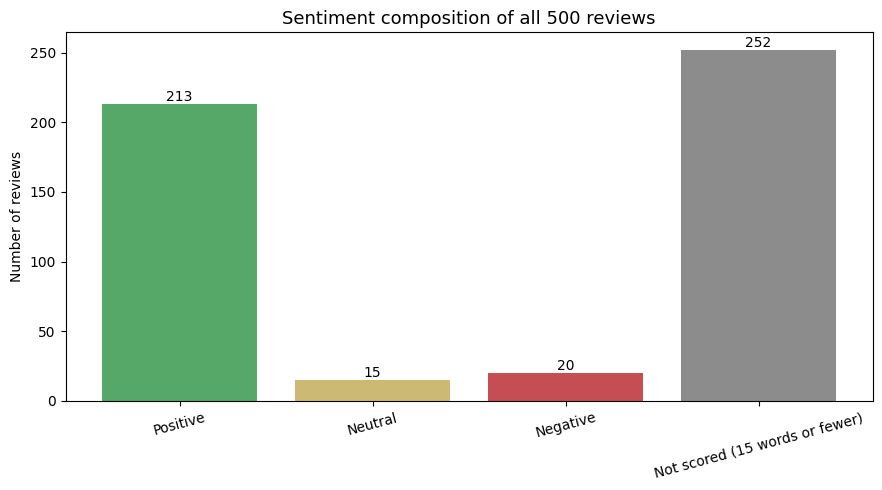

In [46]:
order = ["Positive", "Neutral", "Negative"]
colors = {"Positive": "#55A868", "Neutral": "#CCB974", "Negative": "#C44E52"}

counts = df_long["Sentiment"].value_counts().reindex(order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment label counts
bars = axes[0].bar(counts.index, counts.values, color=[colors[s] for s in counts.index])
axes[0].set_title("Predicted sentiment of reviews with more than 15 words", fontsize=12)
axes[0].set_ylabel("Number of reviews")
for bar, value in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value, f"{int(value)}",
                 ha="center", va="bottom")

# Distribution of the 1-10 scores
axes[1].hist(df_long["Score"].dropna(), bins=range(1, 12), align="left",
             color="#4C72B0", edgecolor="white", rwidth=0.85)
axes[1].set_title("Distribution of predicted sentiment scores (1-10)", fontsize=12)
axes[1].set_xlabel("Sentiment score")
axes[1].set_ylabel("Number of reviews")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

# The full corpus, with the short reviews shown as their own category
full_counts = counts.copy()
full_counts["Not scored (15 words or fewer)"] = num_reviews - len(df_long)

plt.figure(figsize=(9, 5))
bar_colors = [colors.get(label, "#8C8C8C") for label in full_counts.index]
bars = plt.bar(full_counts.index, full_counts.values, color=bar_colors)
for bar, value in zip(bars, full_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{int(value)}",
             ha="center", va="bottom")
plt.title(f"Sentiment composition of all {num_reviews} reviews", fontsize=13)
plt.ylabel("Number of reviews")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Observation.** **213** positive, **15** neutral and **20** negative among the long reviews. The score histogram is the more informative of the two charts, since a cluster at seven and eight reads very differently from a cluster at ten even though both land in the same label.

### **Task 4** : Use OpenAI GPT APIs and prompting engineering to identify key attributes or features mentioned in those negative reviews with more than 15 words

The negative reviews from Task 3 are the input here. Sentiment tells you that customers are unhappy; it does not tell you what they are unhappy about, and that second question is the one a product or merchandising team can act on.

Extraction is a harder prompting problem than classification, because the output is open-ended. Three constraints do most of the work:

Only what is explicitly mentioned. Without this the model volunteers attributes it thinks are relevant to the product category, and the counts in Task 5 stop reflecting the text.
A normalized surface form. Short lower-case noun phrases in the singular, using the standard name for each feature. This is the constraint that Task 5 depends on. If the same complaint comes back as "battery", "the battery", "battery life" and "batteries", the frequency count fragments across four entries and the top-20 list becomes meaningless.
A capped list with a defined empty case. At most five attributes, and an empty array when a review is a general complaint with no specific feature named. Giving the model a legitimate way to say "nothing here" is what stops it from inventing one.
The examples in the prompt carry more weight than the wording of the rules, so the illustrative list covers several product categories rather than a single one.

In [47]:
ATTRIBUTE_PROMPT = """You are analyzing negative customer reviews of Amazon products to find out what customers complain about.

From the review below, extract the product attributes or features that the customer actually mentions. An attribute is a concrete aspect of the product or of the purchase experience, for example: battery life, screen, sound quality, build quality, price, size, fit, material, shipping, packaging, customer service, ease of use, durability, instructions, accuracy.

Rules:
- Only list attributes that are explicitly mentioned or clearly referred to in the review.
- Use short lower-case noun phrases of one to three words, in the singular ("battery life", not "the batteries").
- Use the standard name for each attribute so that the same feature is always written the same way across different reviews.
- List at most five attributes.
- Return a JSON array of strings and nothing else. Return [] if the review names no specific attribute.

Examples:
Review: "The strap broke within a week and it was far too tight to begin with. The seller never replied to my message."
["build quality", "fit", "customer service"]

Review: "Arrived crushed in a flimsy envelope and two pieces were missing from the box."
["packaging", "shipping", "missing parts"]

Review: "Complete garbage. I regret buying this."
[]

Now extract the attributes from this review.
Review: "<<REVIEW>>"
"""

def get_attributes(review):
    raw = call_gpt(ATTRIBUTE_PROMPT.replace("<<REVIEW>>", review))
    attributes = parse_json_response(raw)
    return [a.strip().lower() for a in attributes if isinstance(a, str) and a.strip()]

In [48]:
# Negative reviews with more than 15 words
df_negative = df_long[df_long["Sentiment"] == "Negative"].copy().reset_index(drop=True)
print(f"Negative reviews with more than 15 words: {len(df_negative)}")

extracted = []
for review in tqdm(df_negative["Review"], desc="Extracting attributes"):
    try:
        attributes = get_attributes(review)
    except Exception as e:
        print(f"Failed on review: {review[:60]}... ({e})")
        attributes = []
    extracted.append(attributes)

df_negative["Attributes"] = extracted

# Show a sample of reviews alongside what was extracted from them
df_negative[["Review", "Attributes"]].head(10)

no_attributes = (df_negative["Attributes"].str.len() == 0).sum()
total_mentions = df_negative["Attributes"].str.len().sum()

print(f"Negative reviews processed: {len(df_negative)}")
print(f"Reviews with no specific attribute named: {no_attributes}")
print(f"Total attribute mentions extracted: {total_mentions}")
print(f"Average attributes per negative review: {total_mentions / len(df_negative):.2f}")

Negative reviews with more than 15 words: 20


Extracting attributes: 100%|██████████| 20/20 [00:18<00:00,  1.11it/s]

Negative reviews processed: 20
Reviews with no specific attribute named: 0
Total attribute mentions extracted: 51
Average attributes per negative review: 2.55


### **Task 5** : Identify the most common top-20 attributes or features mentioned in those negative reviews with more than 15 words, and then visualize the occurrences of these top-20 attributes/features in those negative reviews

Counting is the easy half. The part that decides whether the answer is right is the consolidation step that comes first, because even with the normalization rule in the prompt, a few near-duplicates survive - a singular and a plural, or a phrase with and without a leading article.

`normalize_attribute` handles the mechanical cases: it strips punctuation and leading articles, collapses whitespace, and de-pluralizes. A small synonym map then folds the variants that a rule cannot catch, such as "cost" and "value for money" both meaning price. The map is deliberately short and only merges attributes that clearly refer to the same thing; over-merging would hide distinctions that matter, and after running the extraction it is worth checking the raw counts and adding any obvious pairs that show up.

Each attribute is counted once per review rather than once per mention, so a customer who complains twice about the battery in one review does not count double.

In [49]:
from collections import Counter

SYNONYMS = {
    "cost": "price",
    "pricing": "price",
    "value for money": "price",
    "value": "price",
    "battery": "battery life",
    "battery duration": "battery life",
    "sound": "sound quality",
    "audio quality": "sound quality",
    "picture quality": "image quality",
    "delivery": "shipping",
    "shipping time": "shipping",
    "customer support": "customer service",
    "service": "customer service",
    "quality": "build quality",
    "material quality": "material",
    "sizing": "size",
    "instruction manual": "instruction",
    "manual": "instruction",
    "usability": "ease of use",
}

def normalize_attribute(attribute):
    text = attribute.lower().strip()
    text = re.sub(r"[^a-z0-9\s-]", "", text)           # drop punctuation
    text = re.sub(r"^(the|a|an)\s+", "", text)          # drop leading articles
    text = re.sub(r"\s+", " ", text).strip()

    # Singularize the last word so that "batteries" and "battery" are counted together
    words = text.split()
    if words:
        last = words[-1]
        if re.search(r"(ss|us|is)$", last):
            pass                                        # glass, bonus, chassis
        elif last.endswith("ies") and len(last) > 4:
            last = last[:-3] + "y"                      # batteries -> battery
        elif re.search(r"(xes|ches|shes|sses|zzes)$", last):
            last = last[:-2]                            # boxes -> box, watches -> watch
        elif last.endswith("s") and len(last) > 3:
            last = last[:-1]                            # parts -> part, sizes -> size
        words[-1] = last
        text = " ".join(words)

    return SYNONYMS.get(text, text)

# Count each attribute once per review
counter = Counter()
for attributes in df_negative["Attributes"]:
    unique_in_review = {normalize_attribute(a) for a in attributes if normalize_attribute(a)}
    counter.update(unique_in_review)

print(f"Distinct attributes after normalization: {len(counter)}")

top20 = counter.most_common(20)
df_top20 = pd.DataFrame(top20, columns=["Attribute", "Occurrences"])
df_top20.index = range(1, len(df_top20) + 1)
df_top20

Distinct attributes after normalization: 23


,Attribute,Occurrences
1,adhesion,8
2,durability,8
3,color,4
4,build quality,4
5,stickiness,3
6,product type,3
7,adhesive quality,2
8,material,2
9,packaging,2
10,adhesive,2


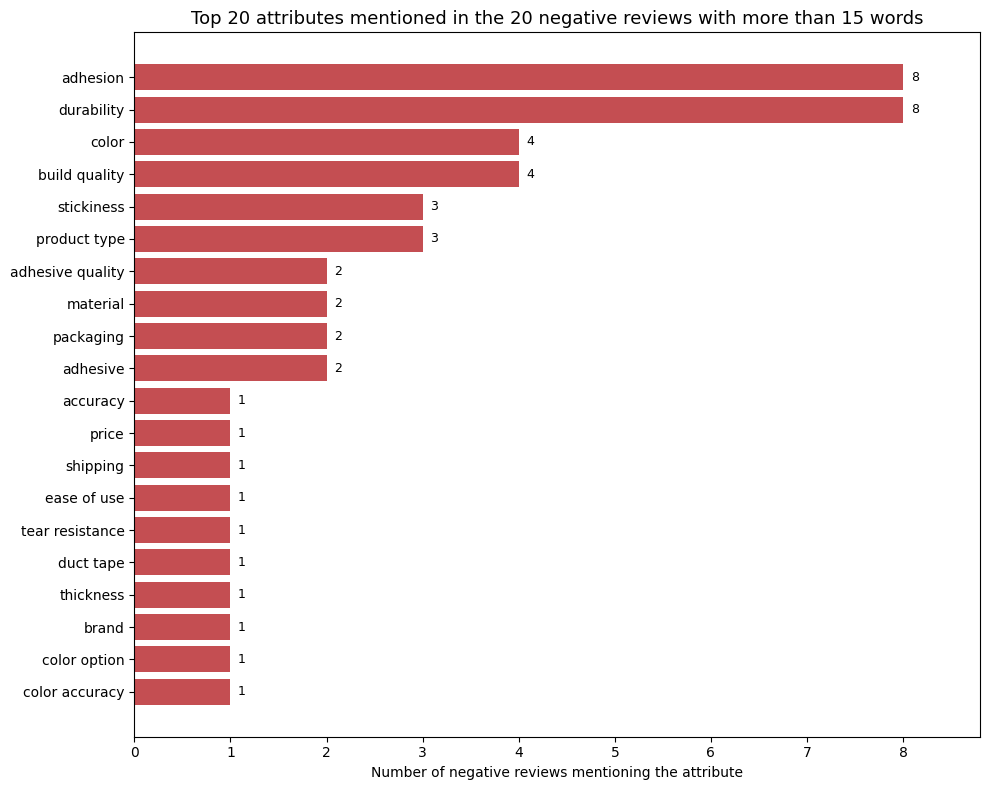

In [50]:
# Visualize the top-20 attributes
assert top20, "No attributes were extracted - check the Task 4 output before plotting."

labels = [attribute for attribute, _ in top20][::-1]
values = [count for _, count in top20][::-1]

plt.figure(figsize=(10, 8))
bars = plt.barh(labels, values, color="#C44E52")
for bar, value in zip(bars, values):
    plt.text(value + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
             str(value), va="center", fontsize=9)
plt.title(f"Top 20 attributes mentioned in the {len(df_negative)} negative reviews "
          f"with more than 15 words", fontsize=13)
plt.xlabel("Number of negative reviews mentioning the attribute")
plt.xlim(0, max(values) * 1.1)
plt.tight_layout()
plt.show()

**Observation.** Name the top three or four attributes here once the chart has run, and say something about the shape of the distribution: a steep drop after the first few means complaints concentrate on a small number of recurring problems, while a flat profile means dissatisfaction is spread thinly across many different features. The first pattern points to a short and specific fix list; the second points to a broader quality issue.